In [1]:
!pip install biopython torch torch-geometric scipy numpy matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 65.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 55.5 MB/s eta 0:00:00


In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import urllib.request
import os

from Bio.PDB import PDBParser
from scipy.spatial.distance import pdist, squareform

from torch_geometric.data import Data
from torch_geometric.nn import SAGEConv

In [3]:
def download_pdb(pdb_id):
    filename = f"{pdb_id}.pdb"
    if not os.path.exists(filename):
        url = f"https://files.rcsb.org/download/{pdb_id}.pdb"
        urllib.request.urlretrieve(url, filename)
    return filename


def load_protein(pdb_file):
    parser = PDBParser()
    structure = parser.get_structure("protein", pdb_file)

    coords = []
    seq = []

    for model in structure:
        for chain in model:
            for residue in chain:
                if "CA" in residue:
                    coords.append(residue["CA"].get_coord())
                    seq.append(residue.get_resname())

    return np.array(coords), seq

In [4]:
def download_pdb(pdb_id):
    filename = f"{pdb_id}.pdb"
    if not os.path.exists(filename):
        url = f"https://files.rcsb.org/download/{pdb_id}.pdb"
        urllib.request.urlretrieve(url, filename)
    return filename


def load_protein(pdb_file):
    parser = PDBParser()
    structure = parser.get_structure("protein", pdb_file)

    coords = []
    seq = []

    for model in structure:
        for chain in model:
            for residue in chain:
                if "CA" in residue:
                    coords.append(residue["CA"].get_coord())
                    seq.append(residue.get_resname())

    return np.array(coords), seq

In [5]:
def build_graph(features):

    N = len(features)
    edges = []
    k = 3

    for i in range(N):
        for j in range(max(0,i-k), min(N,i+k+1)):
            if i != j:
                edges.append([i,j])

    edge_index = torch.tensor(edges).t().contiguous()
    x = torch.tensor(features, dtype=torch.float)

    return Data(x=x, edge_index=edge_index)

In [6]:
amino_acids = [
"ALA","CYS","ASP","GLU","PHE","GLY","HIS",
"ILE","LYS","LEU","MET","ASN","PRO","GLN",
"ARG","SER","THR","VAL","TRP","TYR"
]

aa_to_idx = {aa:i for i,aa in enumerate(amino_acids)}

def encode_sequence(sequence):
    features = []

    for aa in sequence:
        vec = np.zeros(20)
        if aa in aa_to_idx:
            vec[aa_to_idx[aa]] = 1
        features.append(vec)

    return np.array(features)

In [8]:
dataset = []
pdb_list = [
    "1CRN",  # 46
    "1UBQ",  # 76
    "2MCM",  # 113
    "1BTA",  # 89
    "1CAG",  # 88
    "1HHP",  # 99
    "1MBA",  # 146
    "1OAI",  # 68
    "1R69",  # 63
    "2RN2",  # ~100
    "1VII",  # ~70
    "2K39",  # ~100
    "2LZM",  # ~129
    "1PGA",  # ~56
    "1A11",  # ~80
    "1BBL",  # ~40
    "1FME",  # ~98
    "1G6P",  # ~90
    "1LMB",  # ~80
    "1NGL"   # ~120
]

for pdb_id in pdb_list:
    try:
        file = download_pdb(pdb_id)
        coords, seq = load_protein(file)

        # keep only medium-sized proteins
        if len(seq) < 30 or len(seq) > 150:
            print("Skipped (size):", pdb_id)
            continue

        print(pdb_id, "Length:", len(seq))  # DEBUG

        # TEMP: remove strict filtering
        if len(seq) < 20:
            continue

        dist_matrix = squareform(pdist(coords))

        contact_map = (dist_matrix <= 8).astype(int)

        for i in range(len(contact_map)):
            for j in range(len(contact_map)):
                if abs(i-j) < 6:
                    contact_map[i,j] = 0

        features = encode_sequence(seq)
        graph = build_graph(features)

        dataset.append((graph, torch.tensor(contact_map, dtype=torch.float)))

        print("Loaded:", pdb_id)

    except Exception as e:
        print("Skipped:", pdb_id, "| Error:", e)

print("Total proteins:", len(dataset))

1CRN Length: 46
Loaded: 1CRN
1UBQ Length: 76
Loaded: 1UBQ
2MCM Length: 113
Loaded: 2MCM
1BTA Length: 89
Loaded: 1BTA


/usr/local/lib/python3.12/dist-packages/Bio/PDB/StructureBuilder.py:100: PDBConstructionWarning: WARNING: Chain A is discontinuous at line 1039.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/Bio/PDB/StructureBuilder.py:100: PDBConstructionWarning: WARNING: Chain B is discontinuous at line 1043.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/Bio/PDB/StructureBuilder.py:100: PDBConstructionWarning: WARNING: Chain C is discontinuous at line 1051.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/Bio/PDB/StructureBuilder.py:100: PDBConstructionWarning: WARNING: Chain A is discontinuous at line 1063.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/Bio/PDB/StructureBuilder.py:100: PDBConstructionWarning: WARNING: Chain B is discontinuous at line 1091.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/Bio/PDB/StructureBuilder.py:100: PDBConstructionWarning: WARNING: Chain C is discontinuous at line 1117.
  warnings.warn(


1CAG Length: 88
Loaded: 1CAG
1HHP Length: 99
Loaded: 1HHP
1MBA Length: 146
Loaded: 1MBA


/usr/local/lib/python3.12/dist-packages/Bio/PDB/StructureBuilder.py:100: PDBConstructionWarning: WARNING: Chain A is discontinuous at line 1473.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/Bio/PDB/StructureBuilder.py:100: PDBConstructionWarning: WARNING: Chain B is discontinuous at line 1705.
  warnings.warn(


1OAI Length: 68
Loaded: 1OAI
1R69 Length: 63
Loaded: 1R69
Skipped (size): 2RN2
1VII Length: 36
Loaded: 1VII
Skipped (size): 2K39
Skipped (size): 2LZM
1PGA Length: 56
Loaded: 1PGA
Skipped (size): 1A11
1BBL Length: 37
Loaded: 1BBL
Skipped (size): 1FME
Skipped (size): 1G6P


/usr/local/lib/python3.12/dist-packages/Bio/PDB/StructureBuilder.py:100: PDBConstructionWarning: WARNING: Chain 1 is discontinuous at line 2640.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/Bio/PDB/StructureBuilder.py:100: PDBConstructionWarning: WARNING: Chain 2 is discontinuous at line 2676.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/Bio/PDB/StructureBuilder.py:100: PDBConstructionWarning: WARNING: Chain 3 is discontinuous at line 2703.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/Bio/PDB/StructureBuilder.py:100: PDBConstructionWarning: WARNING: Chain 4 is discontinuous at line 2751.
  warnings.warn(


Skipped (size): 1LMB
Skipped (size): 1NGL
Total proteins: 12


In [14]:
class GNN(torch.nn.Module):

    def __init__(self):
        super().__init__()

        self.conv1 = SAGEConv(20,64)
        self.conv2 = SAGEConv(64,128)
        self.dropout = torch.nn.Dropout(0.3)

    def forward(self,x,edge_index):

        x = self.conv1(x,edge_index)
        x = torch.relu(x)
        x = self.dropout(x)

        x = self.conv2(x,edge_index)
        x = torch.relu(x)

        return x


def pairwise(x):

    N = x.shape[0]

    xi = x.unsqueeze(1).repeat(1,N,1)
    xj = x.unsqueeze(0).repeat(N,1,1)

    pair = torch.cat([xi,xj],dim=-1)

    idx = torch.arange(N)
    seq_dist = torch.abs(idx.unsqueeze(1)-idx.unsqueeze(0)).unsqueeze(-1) / N

    pair = torch.cat([pair, seq_dist.float()], dim=-1)

    return pair


class ContactPredictor(torch.nn.Module):

    def __init__(self):
        super().__init__()
        self.fc = torch.nn.Linear(257,1)

    def forward(self,pair):
        return self.fc(pair)


class ContactGNN(torch.nn.Module):

    def __init__(self):
        super().__init__()

        self.gnn = GNN()
        self.pred = ContactPredictor()

    def forward(self,data):

        x = self.gnn(data.x,data.edge_index)
        pair = pairwise(x)
        out = self.pred(pair)

        return out.squeeze(-1)

In [15]:
model = ContactGNN()

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

pos_weight = torch.tensor(2.0)
criterion = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight)

epochs = 250

for epoch in range(epochs):

    total_loss = 0

    for graph, target in dataset:

        optimizer.zero_grad()

        output = model(graph)

        loss = criterion(output, target)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print("Epoch", epoch, "Loss", total_loss)

Epoch 0 Loss 7.506088137626648
Epoch 1 Loss 4.580317795276642
Epoch 2 Loss 3.360367715358734
Epoch 3 Loss 3.465965434908867
Epoch 4 Loss 3.3684998899698257
Epoch 5 Loss 3.3325051814317703
Epoch 6 Loss 3.31961190700531
Epoch 7 Loss 3.3151130825281143
Epoch 8 Loss 3.2908323258161545
Epoch 9 Loss 3.2957082092761993
Epoch 10 Loss 3.276562973856926
Epoch 11 Loss 3.2756375521421432
Epoch 12 Loss 3.256175085902214
Epoch 13 Loss 3.2558826357126236
Epoch 14 Loss 3.2563889622688293
Epoch 15 Loss 3.2487023323774338
Epoch 16 Loss 3.24435555934906
Epoch 17 Loss 3.23486690223217
Epoch 18 Loss 3.234439715743065
Epoch 19 Loss 3.220454916357994
Epoch 20 Loss 3.2225506752729416
Epoch 21 Loss 3.222690224647522
Epoch 22 Loss 3.2087443470954895
Epoch 23 Loss 3.202733650803566
Epoch 24 Loss 3.2043503671884537
Epoch 25 Loss 3.215150475502014
Epoch 26 Loss 3.2031095176935196
Epoch 27 Loss 3.194318026304245
Epoch 28 Loss 3.1875997483730316
Epoch 29 Loss 3.197716772556305
Epoch 30 Loss 3.1869603097438812
Epoch 

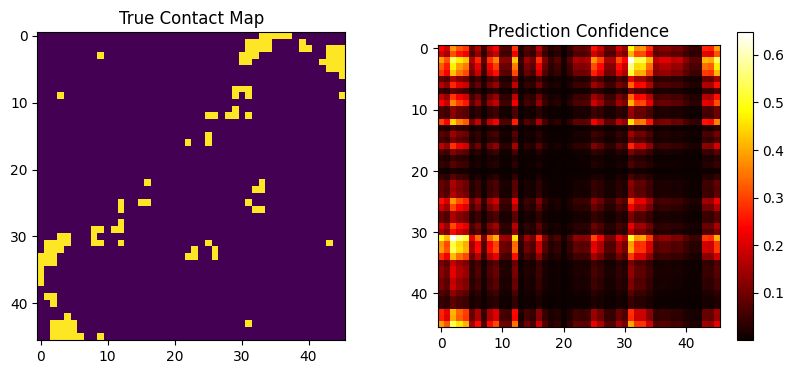

In [16]:
graph, target = dataset[0]

logits = model(graph)

pred = torch.sigmoid(logits)

L = pred.shape[0]
top_k = L // 5

flat = pred.flatten()
indices = torch.topk(flat, top_k).indices

pred_contact = torch.zeros_like(flat)
pred_contact[indices] = 1

pred_contact = pred_contact.view(L, L)

# enforce symmetry
pred_contact = (pred_contact + pred_contact.T) // 2

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(target)
plt.title("True Contact Map")

plt.subplot(1,2,2)
plt.imshow(pred.detach().numpy(), cmap="hot")
plt.title("Prediction Confidence")
plt.colorbar()
plt.show()

In [17]:
def accuracy(pred, target):
    pred = pred.flatten()
    target = target.flatten()
    return (pred == target).sum().item() / len(target)


def precision(pred, target):
    tp = ((pred == 1) & (target == 1)).sum().item()
    fp = ((pred == 1) & (target == 0)).sum().item()
    return tp / (tp + fp + 1e-8)


def recall(pred, target):
    tp = ((pred == 1) & (target == 1)).sum().item()
    fn = ((pred == 0) & (target == 1)).sum().item()
    return tp / (tp + fn + 1e-8)


def f1_score(pred, target):
    p = precision(pred, target)
    r = recall(pred, target)
    return 2 * (p * r) / (p + r + 1e-8)


def precision_at_L(pred_scores, target, L):
    pred_scores = pred_scores.flatten()
    target = target.flatten()
    topk = torch.topk(pred_scores, L//10).indices
    selected = target[topk]
    return selected.sum().item() / (len(selected) + 1e-8)


def precision_at_L5(pred_scores, target, L):

    pred_scores = pred_scores.flatten()
    target = target.flatten()

    topk = torch.topk(pred_scores, L // 5).indices

    selected = target[topk]

    return selected.sum().item() / (len(selected) + 1e-8)

In [18]:
print("Accuracy:", accuracy(pred_contact, target))
print("Precision:", precision(pred_contact, target))
print("Recall:", recall(pred_contact, target))
print("F1 Score:", f1_score(pred_contact, target))
print("Precision@L/10:", precision_at_L(pred, target, len(target)))
print("Precision@L/5:", precision_at_L5(pred, target, len(target)))

Accuracy: 0.9484877126654064
Precision: 0.8888888879012344
Recall: 0.06896551723543401
F1 Score: 0.12799999864320002
Precision@L/10: 0.9999999975
Precision@L/5: 0.8888888879012344
